Regions: ['East' 'Central' 'West']
Null region: 0

Absolute revenue by region (B VND):
region  Central  East  West
year                       
2012       0.18  0.29  0.15
2013       0.41  0.66  0.33
2014       0.45  0.74  0.39
2015       0.44  0.75  0.40
2016       0.51  0.82  0.45
2017       0.47  0.75  0.40
2018       0.50  0.70  0.35
2019       0.31  0.44  0.21
2020       0.29  0.41  0.19
2021       0.29  0.41  0.17
2022       0.32  0.45  0.20

Revenue share (%):
region  Central  East  West
year                       
2012       28.5  47.0  24.5
2013       29.2  47.1  23.7
2014       28.2  47.1  24.7
2015       27.6  47.3  25.1
2016       28.7  46.2  25.1
2017       29.0  46.3  24.6
2018       32.2  45.1  22.7
2019       32.2  45.9  21.9
2020       32.8  46.0  21.2
2021       33.0  47.2  19.8
2022       32.7  46.7  20.6


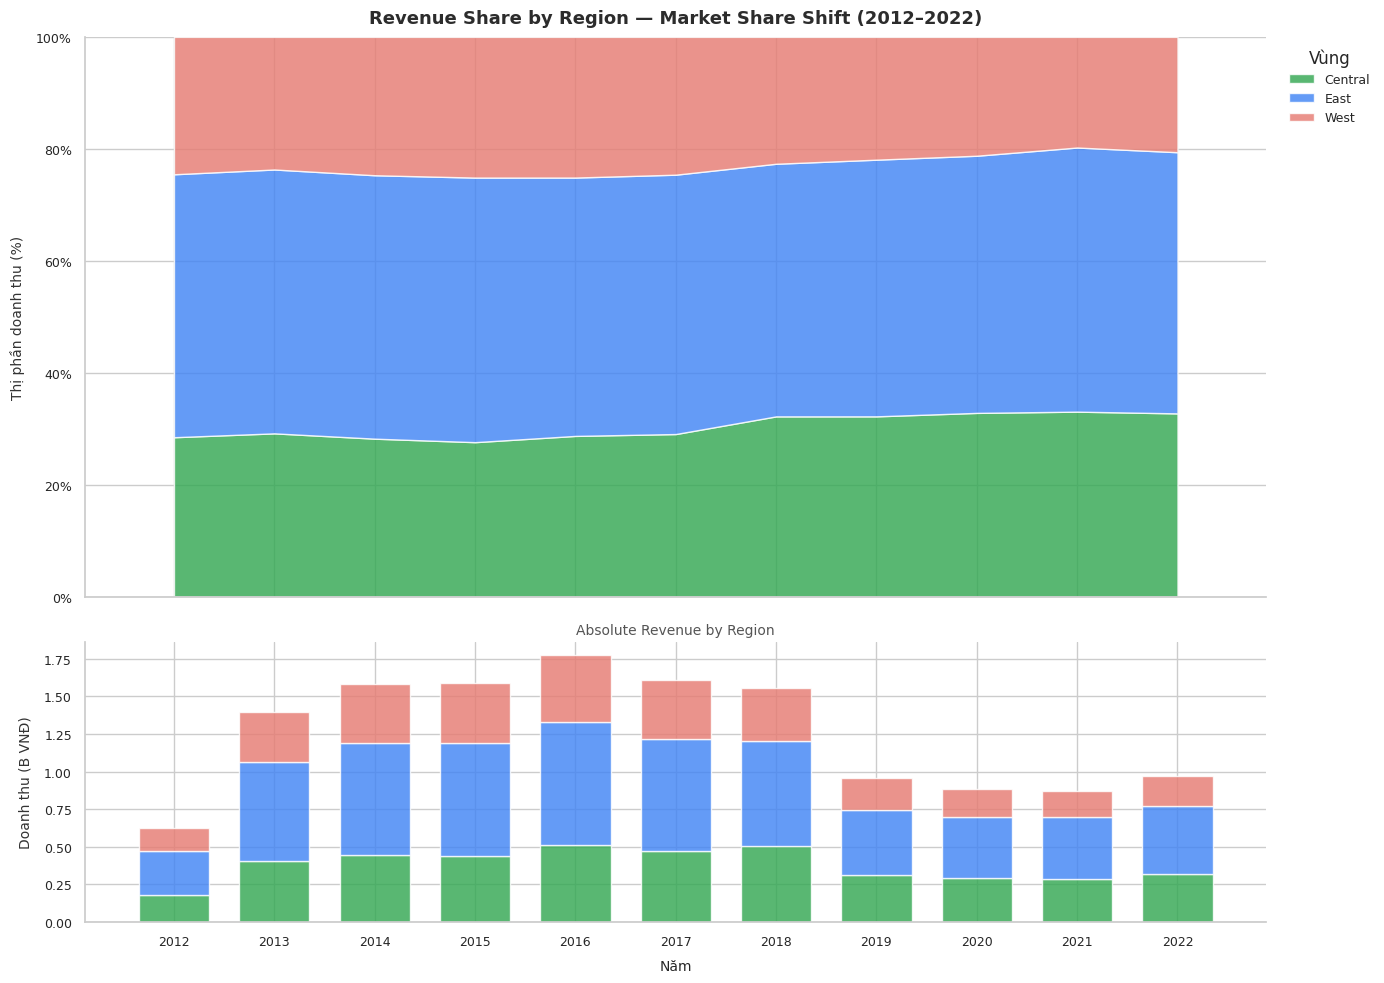


Saved: d:\BountyHunter\reports\figures\chart_1c.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os

root_dir      = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
processed_dir = os.path.join(root_dir, "data", "processed")
output_dir    = os.path.join(root_dir, "reports", "figures")
os.makedirs(output_dir, exist_ok=True)

sns.set_theme(style="whitegrid", font="DejaVu Sans")

def generate_chart_1c():

    # ── 1. LOAD ───────────────────────────────────────────────────
    orders   = pd.read_parquet(os.path.join(processed_dir, "orders.parquet"))
    items    = pd.read_parquet(os.path.join(processed_dir, "order_items.parquet"))
    geo      = pd.read_parquet(os.path.join(processed_dir, "geography.parquet"))

    # ── 2. FILTER ─────────────────────────────────────────────────
    valid_statuses = ["delivered", "shipped", "paid"]
    orders = orders[orders["order_status"].isin(valid_statuses)].copy()

    # ── 3. REVENUE PER ORDER ──────────────────────────────────────
    # unit_price da la gia sau giam → khong tru them discount_amount
    items["item_revenue"] = items["unit_price"] * items["quantity"]
    order_rev = (
        items.groupby("order_id")["item_revenue"]
        .sum()
        .reset_index(name="order_revenue")
    )

    # ── 4. JOIN ───────────────────────────────────────────────────
    df = (
        orders[["order_id", "order_date", "zip"]]
        .merge(geo[["zip", "region"]], on="zip", how="left")
        .merge(order_rev, on="order_id", how="left")
    )
    df["year"] = df["order_date"].dt.year

    # ── 5. SANITY CHECK ───────────────────────────────────────────
    print("Regions:", df["region"].unique())
    print("Null region:", df["region"].isna().sum())

    # ── 6. AGGREGATE ──────────────────────────────────────────────
    # Absolute revenue theo nam x region
    rev_abs = (
        df.groupby(["year", "region"])["order_revenue"]
        .sum()
        .unstack()
        .fillna(0)
        .sort_index()
    )

    # Normalize 100%
    rev_pct = rev_abs.div(rev_abs.sum(axis=1), axis=0) * 100

    print("\nAbsolute revenue by region (B VND):")
    print((rev_abs / 1e9).round(2))
    print("\nRevenue share (%):")
    print(rev_pct.round(1))

    # ── 7. COLORS & ORDER ─────────────────────────────────────────
    # lay danh sach regions thuc te tu data
    regions = list(rev_pct.columns)
    color_map = {
        "Central" : "#34A853",
        "East"    : "#4285F4",
        "West"    : "#E67C73",
        "North"   : "#FBBC04",
        "South"   : "#9C27B0",
    }
    colors = [color_map.get(r, "#607D8B") for r in regions]

    # ── 8. VE ─────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(14, 10),
        gridspec_kw={"height_ratios": [2, 1]},
        sharex=True
    )
    fig.patch.set_facecolor("white")

    # ── Panel trên: 100% stacked area (thi phan) ──────────────────
    ax1.stackplot(
        rev_pct.index,
        [rev_pct[r].values for r in regions],
        labels=regions,
        colors=colors,
        alpha=0.82
    )

    ax1.set_ylim(0, 100)
    ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax1.set_ylabel("Thị phần doanh thu (%)",
                   fontsize=10, color="#333333", labelpad=8)
    ax1.set_title(
        "Revenue Share by Region — Market Share Shift (2012–2022)",
        fontsize=13, fontweight="bold", color="#2C2C2C", pad=10
    )
    ax1.legend(
        loc="upper left", bbox_to_anchor=(1.01, 1),
        title="Vùng", fontsize=9, frameon=False
    )
    ax1.spines[["top", "right"]].set_visible(False)
    ax1.tick_params(axis="y", labelsize=9)

    # annotation: concentration risk neu 1 vung > 50%
    dominant = rev_pct.idxmax(axis=1)
    dominant_pct = rev_pct.max(axis=1)
    for yr in rev_pct.index:
        if dominant_pct[yr] > 55:
            ax1.annotate(
                f"{dominant[yr]}\n{dominant_pct[yr]:.0f}%",
                xy=(yr, dominant_pct[yr] / 2),
                ha="center", va="center",
                fontsize=7, color="white",
                fontweight="bold", alpha=0.85
            )

    # ── Panel duoi: absolute revenue (B VND) ──────────────────────
    bottom = pd.Series(0, index=rev_abs.index, dtype=float)
    for region, color in zip(regions, colors):
        ax2.bar(
            rev_abs.index,
            rev_abs[region] / 1e9,
            bottom=bottom,
            color=color,
            alpha=0.82,
            width=0.7,
            label=region
        )
        bottom += rev_abs[region] / 1e9

    ax2.set_ylabel("Doanh thu (B VNĐ)",
                   fontsize=10, color="#333333", labelpad=8)
    ax2.set_xlabel("Năm", fontsize=10, labelpad=8)
    ax2.set_title(
        "Absolute Revenue by Region",
        fontsize=10, color="#555555", pad=6
    )
    ax2.spines[["top", "right"]].set_visible(False)
    ax2.tick_params(axis="both", labelsize=9)
    ax2.set_xticks(rev_abs.index)

    # ── 9. SHARED FORMATTING ──────────────────────────────────────
    plt.tight_layout()

    save_path = os.path.join(output_dir, "chart_1c.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"\nSaved: {save_path}")

generate_chart_1c()